<a href="https://colab.research.google.com/github/mashka15/karpova/blob/main/Karpova_Kudr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Загрузка набора готовых признаков
data_features = pd.read_csv('dataset.csv')

# Загрузка телеметрических сегментов (временные ряды)
data_segments = pd.read_csv('segments.csv')

print("dataset.csv shape:", data_features.shape)
print("segments.csv shape:", data_segments.shape)

# Просмотр первых строк
display(data_features.head())
display(data_segments.head())

dataset.csv shape: (2123, 23)
segments.csv shape: (303493, 8)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,309,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,644,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,772,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,339,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,255,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,357,257,2.070205e-12,2.054094e-12


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-06-01T23:42:54.000Z,-0.000021,anomaly,1,1,1,1
1,CADC0872,2022-06-01T23:42:55.000Z,-0.000021,anomaly,1,1,1,1
2,CADC0872,2022-06-01T23:42:56.000Z,-0.000021,anomaly,1,1,1,1
3,CADC0872,2022-06-01T23:42:57.000Z,-0.000021,anomaly,1,1,1,1
4,CADC0872,2022-06-01T23:42:58.000Z,-0.000021,anomaly,1,1,1,1


# 1. Файл dataset.csv:


*   Этот файл содержит вычисленные признаки и метки для задач классификации, подходящие для машинного обучения и аномалии.

*   Структура данных в dataset.csv:
Размер: 2123 строки и 23 столбца.
Признаки: каждый столбец представляет собой признак (например, различные статистики по телеметрии, такие как среднее, стандартное отклонение, максимальные и минимальные значения и т.д.).

*   Метки: последние столбцы, вероятно, включают метки классов для классификации (например, "аномалия" или "нормальное состояние").

*   Основные столбцы:
segment: идентификатор сегмента телеметрии.
anomaly: метка, указывающая на аномалию (1 — есть аномалия, 0 — нет).
mean: среднее значение для сегмента.
var: дисперсия в сегменте.
std: стандартное отклонение.
len: длина сегмента.
other features: могут быть различные статистические данные, такие как частота, пики, изменения и т.д.

# 2. Файл segments.csv:


*   Этот файл содержит сырые телеметрические данные, которые представляют собой последовательности значений в различные моменты времени, а также некоторые метки и признаки.

*   Структура данных в segments.csv:
Размер: 303493 строки и 8 столбцов.
Каждая строка: представляет собой точку телеметрии, связанного с определённым сегментом космического аппарата.

*   Основные столбцы:
channel: название канала телеметрии (например, "CADC0872").
timestamp: временная метка для данных телеметрии.
value: значение параметра в момент времени.
label: метка, указывающая на состояние (например, "анализ" или "неанализ").
anomaly: индикатор аномалии (0 — нет, 1 — есть).
segment: идентификатор сегмента (ссылается на идентификатор сегмента из dataset.csv).
train: возможно, индикатор того, используется ли этот сегмент для обучения (1 — да, 0 — нет).

*   Примечание:
Этот файл содержит более детализированные данные (по каждому измерению во времени), и может быть использован для создания более сложных моделей, работающих с временными рядами, таких как сверточные нейронные сети (CNN) и рекуррентные нейронные сети (GRU).


# Шаг 2: Переразметка данных для бинарной классификации

В вашем задании необходимо выполнить переразметку исходного набора данных для бинарной классификации. В частности, нужно объединить метки "отказ" и "сбой" в один класс "нештатное состояние" и оставить "штатное функционирование" как отдельный класс.

Действия:
Объединение классов:
Класс 0 — "штатное функционирование" (изначально у нас будет метка 0).
Класс 1 — "нештатное состояние" (включает метки отказ и сбой).
Мы преобразуем данные в бинарный формат: 0 (штатное) и 1 (нештатное).


**2.1. Переразметка меток в dataset.csv**

In [2]:
# Проверим уникальные метки
print(data_features['anomaly'].unique())

# Переразметим метки для бинарной классификации
data_features['anomaly'] = data_features['anomaly'].map({0: 0, 1: 1, 2: 1})

# Проверим результат переразметки
print(data_features['anomaly'].value_counts())

[1 0]
anomaly
0    1689
1     434
Name: count, dtype: int64


Объяснение:
Мы заменили метки 1 и 2 (отказ и сбой) на 1 для обозначения "нештатного состояния".
Мы оставили 0 как есть для "штатного состояния".

Результат будет бинарным — 0 для штатного функционирования и 1 для нештатного состояния.

**2.2. Переразметка меток в segments.csv**

Если в segments.csv у вас есть метки, которые также содержат аномалии, мы аналогично переразметим их в бинарный формат.

In [3]:
# Проверим уникальные метки в 'segments.csv'
print(data_segments['anomaly'].unique())

# Переразметим метки для бинарной классификации
data_segments['anomaly'] = data_segments['anomaly'].map({0: 0, 1: 1})

# Проверим результат переразметки
print(data_segments['anomaly'].value_counts())

[1 0]
anomaly
0    203229
1    100264
Name: count, dtype: int64


Объяснение:
Мы здесь точно так же заменили метки:
1 → 1 (нештатное состояние)
0 → 0 (штатное состояние)
Теперь оба файла будут подготовлены для бинарной классификации.

2.3. Проверка результата
После того как мы переразметили данные, полезно будет проверить, что изменения корректны и всё работает как нужно. Мы можем посмотреть на распределение классов и проверить, нет ли ошибок в разметке.

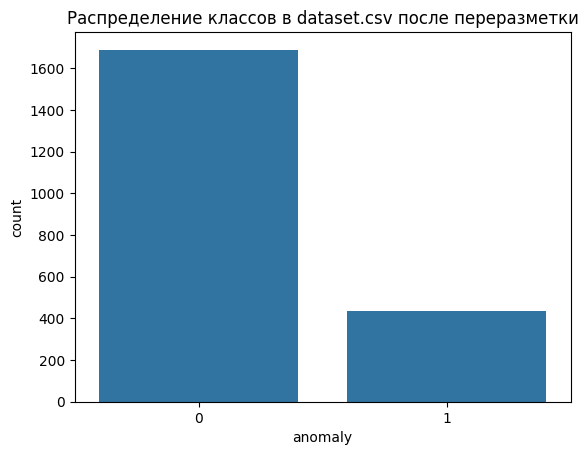

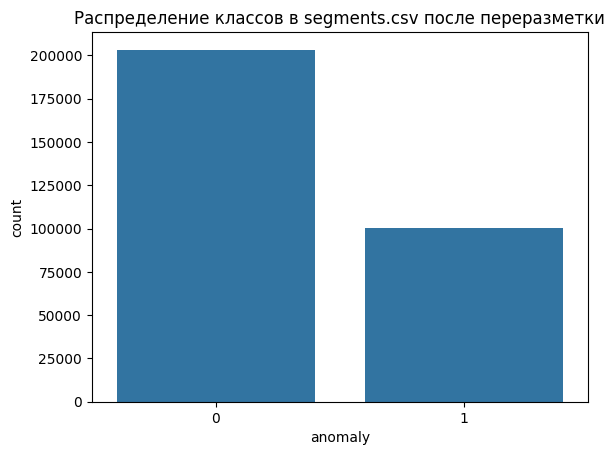

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Проверим распределение классов в обоих наборах данных
sns.countplot(x='anomaly', data=data_features)
plt.title('Распределение классов в dataset.csv после переразметки')
plt.show()

sns.countplot(x='anomaly', data=data_segments)
plt.title('Распределение классов в segments.csv после переразметки')
plt.show()

Шаг 3: Разведочный анализ данных (EDA)
Разведочный анализ данных (EDA) — это процесс, который позволяет понять структуру данных, выявить основные закономерности, а также проверить, есть ли аномалии, пропуски или проблемы с данными.

Мы уже начали его выполнять, но давайте подробнее рассмотрим следующие шаги для более глубокого анализа:

3.1. Просмотр структуры данных
Мы уже загружали и посмотрели данные в dataset.csv и segments.csv. На следующем этапе важно проверить:

Признаки и метки
Статистику по каждому из признаков
Есть ли пропуски в данных


In [6]:
# Проверим структуру данных для обоих файлов
print("Размеры и первые строки dataset.csv:")
print(data_features.shape)
print(data_features.head())

print("\nРазмеры и первые строки segments.csv:")
print(data_segments.shape)
print(data_segments.head())

# Статистика по данным
print("\nСтатистика по dataset.csv:")
display(data_features.describe())

print("\nСтатистика по segments.csv:")
display(data_segments.describe())

Размеры и первые строки dataset.csv:
(2123, 23)
   segment  anomaly  train   channel  sampling  duration  len          mean  \
0        1        1      1  CADC0872         1       279  280  8.533143e-07   
1        2        1      1  CADC0872         1       476  477 -3.639396e-06   
2        3        1      1  CADC0872         1       594  595  1.170788e-05   
3        4        1      1  CADC0872         1       271  272  8.486808e-07   
4        5        0      0  CADC0872         1       255  257  1.058485e-05   

            var       std  ...  smooth10_n_peaks  smooth20_n_peaks  \
0  3.494283e-10  0.000019  ...                 3                 2   
1  6.476485e-10  0.000025  ...                 1                 1   
2  5.592877e-10  0.000024  ...                 2                 2   
3  5.466024e-10  0.000023  ...                 2                 2   
4  5.279023e-10  0.000023  ...                 1                 1   

   diff_peaks  diff2_peaks      diff_var     diff2_var  

,segment,anomaly,train,sampling,duration,len,mean,var,std,kurtosis,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
count,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2.123000e+03,2.123000e+03,2123.000000,2123.000000,...,2123.000000,2123.000000,2123.000000,2123.000000,2.123000e+03,2.123000e+03,2123.000000,2123.000000,2.123000e+03,2.123000e+03
mean,1062.000000,0.204428,0.750824,3.505888,267.952426,142.954781,1.109677e-01,3.065868e-02,0.096226,-1.085494,...,1.110221,1.181818,18.110692,25.286387,9.166359e-04,1.045846e-03,1027.671691,267.925106,1.159496e-04,4.361427e-04
std,613.001631,0.403378,0.432638,1.935418,169.093207,152.329786,1.963165e-01,5.491161e-02,0.146319,1.000566,...,0.399227,0.425295,28.991979,32.737797,4.196259e-03,1.127395e-02,1555.230980,166.245528,2.091082e-04,8.845658e-04
min,1.000000,0.000000,0.000000,1.000000,35.000000,8.000000,-3.833030e-05,1.422763e-11,0.000004,-1.858813,...,0.000000,0.000000,0.000000,0.000000,1.962330e-13,3.875356e-13,126.000000,40.000000,2.817267e-14,4.404840e-14
25%,531.500000,0.000000,1.000000,1.000000,175.000000,40.000000,-7.239804e-07,2.960552e-10,0.000017,-1.449123,...,1.000000,1.000000,1.000000,4.000000,3.163852e-12,1.233331e-12,358.000000,175.000000,1.310632e-12,2.809916e-12
50%,1062.000000,0.000000,1.000000,5.000000,225.000000,70.000000,4.515496e-06,6.032890e-10,0.000025,-1.302729,...,1.000000,1.000000,5.000000,14.000000,3.640618e-11,1.095135e-11,575.000000,230.000000,3.761334e-12,1.563517e-11
75%,1592.500000,0.000000,1.000000,5.000000,336.000000,201.000000,2.051710e-01,3.738843e-02,0.193361,-0.996211,...,1.000000,1.000000,21.000000,32.000000,2.982598e-04,1.402282e-04,1200.000000,330.000000,1.827432e-04,4.718514e-04
max,2123.000000,1.000000,1.000000,5.000000,1335.000000,1040.000000,1.118632e+00,2.724801e-01,0.521996,31.201842,...,5.000000,4.000000,240.000000,256.000000,9.987869e-02,3.033986e-01,20750.000000,1340.000000,1.686516e-03,8.031028e-03



Статистика по segments.csv:


,value,sampling,anomaly,segment,train
count,303493.000000,303493.000000,303493.000000,303493.000000,303493.000000
mean,0.084209,1.874195,0.330367,773.451539,0.741955
std,0.224150,1.653049,0.470346,587.748209,0.437560
min,-0.000101,1.000000,0.000000,1.000000,0.000000
25%,-0.000005,1.000000,0.000000,283.000000,0.000000
50%,0.000005,1.000000,0.000000,619.000000,1.000000
75%,0.000037,1.000000,1.000000,1031.000000,1.000000
max,1.570800,5.000000,1.000000,2123.000000,1.000000


3.2. Распределение классов
Теперь, когда мы переразметили данные для бинарной классификации, важно увидеть распределение классов:
Мы уже выполняли это для dataset.csv и segments.csv, но стоит еще раз убедиться в балансировке классов.

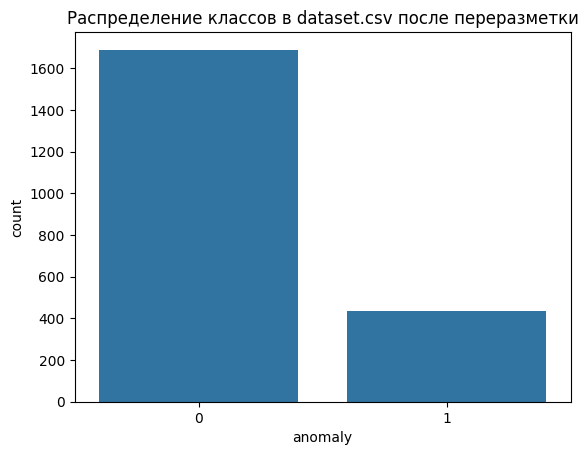

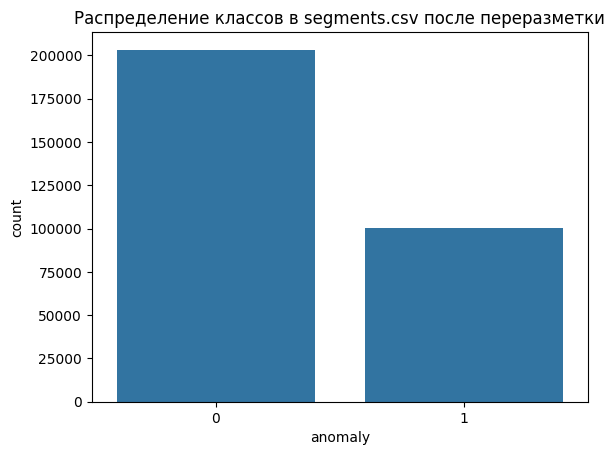

In [7]:
# Распределение классов по метке 'anomaly' для обоих файлов
sns.countplot(x='anomaly', data=data_features)
plt.title('Распределение классов в dataset.csv после переразметки')
plt.show()

sns.countplot(x='anomaly', data=data_segments)
plt.title('Распределение классов в segments.csv после переразметки')
plt.show()

3.3. Дополнительный анализ признаков
Для более глубокого анализа стоит посмотреть на основные статистики признаков в данных:
Для числовых признаков (например, mean, std, len, var) полезно построить гистограммы и диаграммы рассеяния.

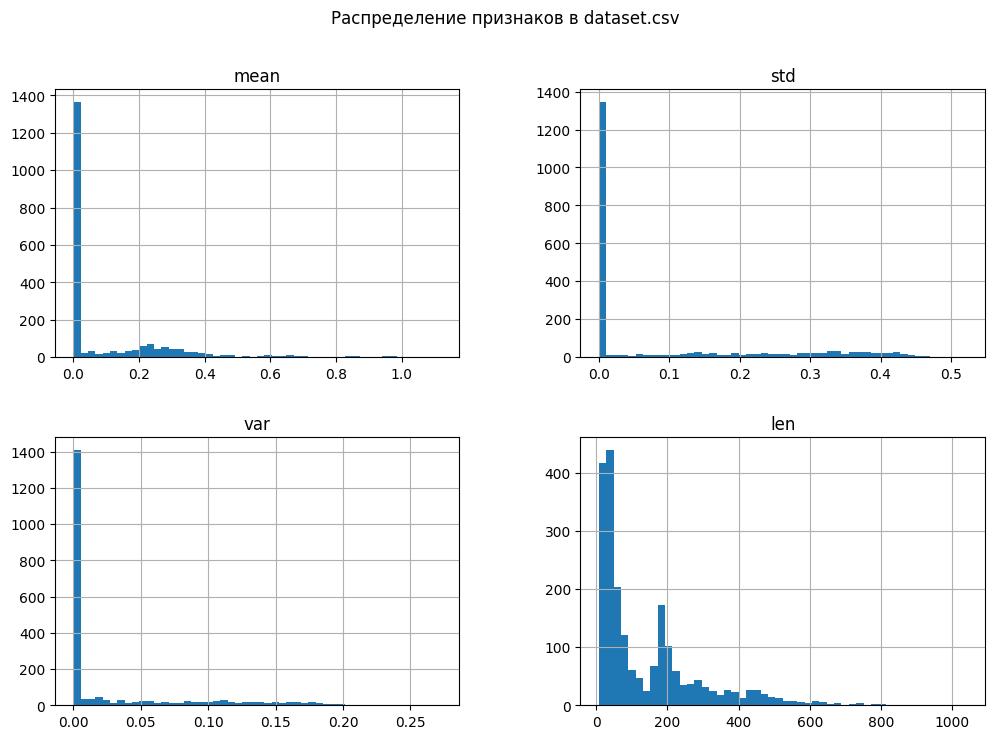

In [8]:
# Гистограммы для некоторых признаков
features_to_check = ['mean', 'std', 'var', 'len']

data_features[features_to_check].hist(figsize=(12, 8), bins=50)
plt.suptitle('Распределение признаков в dataset.csv')
plt.show()

3.4. Проверка на выбросы
Выбросы могут существенно повлиять на качество модели, так что важно выявить их на этом этапе. Для этого можно использовать:
boxplot для визуализации выбросов.

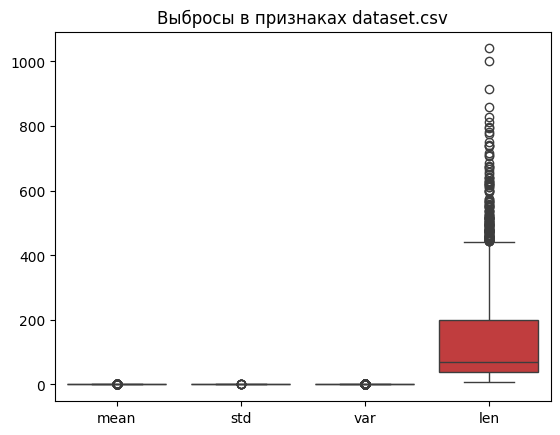

In [9]:
# Boxplot для выявления выбросов в признаках
sns.boxplot(data=data_features[features_to_check])
plt.title('Выбросы в признаках dataset.csv')
plt.show()

3.5. Проверка на пропуски
Мы уже проверяли наличие пропусков в данных, но важно еще раз это сделать для каждого столбца и проверить, если нужно, заполнить или удалить пропуски.

In [10]:
# Проверка на пропуски в данных
print("Пропуски в dataset.csv:")
print(data_features.isnull().sum())

print("\nПропуски в segments.csv:")
print(data_segments.isnull().sum())

Пропуски в dataset.csv:
segment             0
anomaly             0
train               0
channel             0
sampling            0
duration            0
len                 0
mean                0
var                 0
std                 0
kurtosis            0
skew                0
n_peaks             0
smooth10_n_peaks    0
smooth20_n_peaks    0
diff_peaks          0
diff2_peaks         0
diff_var            0
diff2_var           0
gaps_squared        0
len_weighted        0
var_div_duration    0
var_div_len         0
dtype: int64

Пропуски в segments.csv:
channel      0
timestamp    0
value        0
label        0
sampling     0
anomaly      0
segment      0
train        0
dtype: int64


Шаг 4: Подготовка данных для модели
Теперь, когда мы очистили данные и проверили на пропуски, мы можем продолжить подготовку для обучения модели. Мы будем:
Нормализовать признаки.
Разделим данные на обучающую и тестовую выборки.
Подготовим модель для обучения.
4.1. Нормализация данных
Мы уже загрузили данные и переразметили их. Теперь давайте применим нормализацию признаков с использованием StandardScaler, чтобы привести данные к стандартному виду.

In [13]:
# Исключим категориальные столбцы (например, 'segment' и 'channel')
X = data_features.drop(columns=['anomaly', 'segment', 'channel'])  # Признаки
y = data_features['anomaly']  # Метки

# Нормализуем только числовые признаки
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Применяем к данным для обучения

# Проверим нормализованные данные
print("Размер данных после нормализации:", X_scaled.shape)

Размер данных после нормализации: (2123, 20)


4.2 Разделение данных на обучающую и тестовую выборки
Мы разделим данные на 80% для обучения и 20% для тестирования. Это нужно сделать до того, как мы начнем обучение модели.

In [14]:
from sklearn.model_selection import train_test_split

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Проверим размеры полученных выборок
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1698, 20)
Размер тестовой выборки: (425, 20)


4.3 Проверка на пропуски в данных
Хотя мы уже проверяли на пропуски в предыдущем шаге, давайте еще раз убедимся, что в обучающих и тестовых данныхх нет пропусков. Это важный шаг, чтобы убедиться, что данные не содержат "незаполненные" значения, которые могут повлиять на обучение модели.

In [15]:
# Проверка на пропуски в обучающих данных
print("Пропуски в обучающих данных (X_train):")
print(pd.DataFrame(X_train).isnull().sum())

# Проверка на пропуски в тестовых данных
print("\nПропуски в тестовых данных (X_test):")
print(pd.DataFrame(X_test).isnull().sum())

Пропуски в обучающих данных (X_train):
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

Пропуски в тестовых данных (X_test):
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64


4.4 Построение классификационной модели
Когда данные готовы, мы переходим к построению модели. Используем RandomForestClassifier для быстрой проверки.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Построение модели случайного леса
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
y_pred = clf.predict(X_test)

# Оценка модели
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       337
           1       0.96      0.85      0.90        88

    accuracy                           0.96       425
   macro avg       0.96      0.92      0.94       425
weighted avg       0.96      0.96      0.96       425

Accuracy: 0.9623529411764706


Теперь у нас есть:
Разделение данных на обучающие и тестовые выборки.
Проверка пропусков для всех данных.
Обучение модели с использованием Random Forest.

# Шаг 5: Оценка модели

После того, как модель обучена, нам нужно провести ее оценку с использованием нескольких важных метрик:
Accuracy (Точность) — процент правильных предсказаний.
Precision — доля верных положительных предсказаний среди всех предсказанных положительных.
Recall — доля верных положительных предсказаний среди всех фактических положительных.
F1-score — гармоническое среднее между Precision и Recall, полезно, когда классы несбалансированы.
ROC-AUC — площадь под кривой ошибок, что помогает оценить способность модели различать классы.


5.1 Оценка на тестовой выборке
Используем метод classification_report и accuracy_score для оценки точности модели и других метрик:

In [17]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Оценка модели на тестовой выборке
y_pred = clf.predict(X_test)

# Выводим основные метрики
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Оценка ROC-AUC для бинарной классификации
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc_auc)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       337
           1       0.96      0.85      0.90        88

    accuracy                           0.96       425
   macro avg       0.96      0.92      0.94       425
weighted avg       0.96      0.96      0.96       425

Accuracy: 0.9623529411764706
ROC-AUC: 0.921685325060696


5.2 График ROC-кривой
ROC-кривая позволяет визуализировать производительность модели при различных порогах классификации. Мы можем построить ROC-кривую с помощью roc_curve из sklearn.

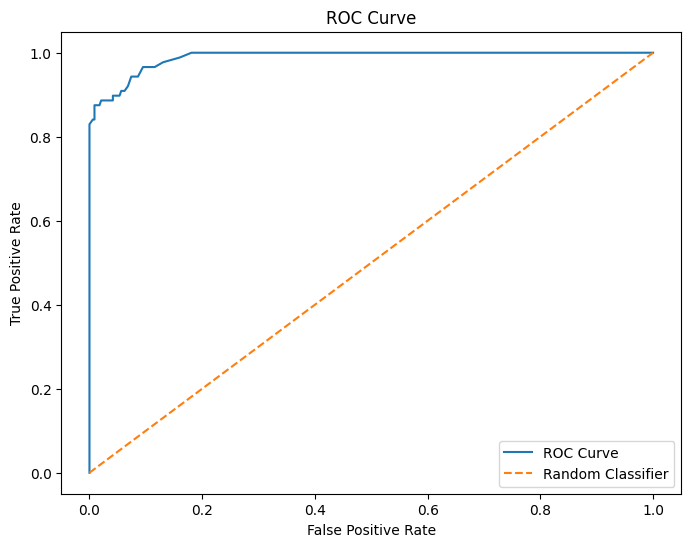

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Получаем вероятности для каждого класса
y_probs = clf.predict_proba(X_test)[:, 1]  # Вероятности для положительного класса

# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

5.3 Подведение итогов
После выполнения этих шагов, мы получим:
Точные метрики: точность, полнота, F1-оценка.
ROC-AUC: оценка способности модели различать классы.
ROC-кривая: визуализация производительности модели.
Это позволит нам оценить, насколько хорошо работает наша модель и какие улучшения могут быть полезны для дальнейшего улучшения точности (например, с использованием более сложных моделей или гиперпараметрической настройки).

# Шаг 6: Построение автокодировщика для предобучения или аномалий
В зависимости от того, какой вариант выбран, мы будем строить автокодировщик для:
Предобучения модели (для варианта 1.1), или
Обнаружения аномалий (для варианта 1.2).
**6.1. Вариант 1.1: Предобучение с помощью автокодировщика**

В этом случае автокодировщик будет использоваться для извлечения признаков из неразмеченной части данных. После предобучения мы будем использовать эти признаки для дообучения базовой нейросети с размеченными данными.


Что такое автокодировщик?
Автокодировщик — это нейронная сеть, которая учится сжать входные данные в более компактное представление и затем восстанавливать их. Это полезно для обучения без учителя, извлекая важные признаки.


Мы будем строить автокодировщик, который будет:
Сжать данные в скрытое представление.
Восстановить исходные данные.


Реализация автокодировщика:
Строим модель автокодировщика.
Обучаем модель на неразмеченных данных.
Используем скрытые представления для дообучения основной классификационной модели.
Код для автокодировщика:

In [19]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Строим автокодировщик
input_data = Input(shape=(X_train.shape[1],))
encoded = Dense(128, activation='relu')(input_data)  # Сжимаем данные
decoded = Dense(X_train.shape[1], activation='sigmoid')(encoded)  # Восстанавливаем данные

autoencoder = Model(input_data, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Обучение автокодировщика на обучающих данных (неразмеченные данные)
autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

# Получаем скрытые представления
encoder = Model(input_data, encoded)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

print("Размер скрытых представлений (X_train_encoded):", X_train_encoded.shape)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 1.2049 - val_loss: 1.1805
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.1370 - val_loss: 1.1136
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1378 - val_loss: 1.0495
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9844 - val_loss: 0.9880
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9611 - val_loss: 0.9300
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8963 - val_loss: 0.8775
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8398 - val_loss: 0.8322
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8571 - val_loss: 0.7951
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7407 - val_loss: 0.7657
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7267 - val_loss: 0.7429
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7520 - val_loss: 0.7251
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7131 - val_loss: 0.7109
E

**6.2. Вариант 1.2: Обнаружение аномалий с помощью автокодировщика**

Для этого варианта мы построим автокодировщик, который будет использоваться для обнаружения аномалий. Сеть будет обучена на нормальных данных, а затем будет проверять, насколько хорошо она восстанавливает данные. Если ошибка восстановления высокая, это будет сигнализировать о наличии аномалии.

Что будет изменено:
Вместо восстановления данных, мы будем анализировать ошибку восстановления и использовать её для классификации.
Мы будем использовать восстановление ошибки для классификации аномалий.
Код для обнаружения аномалий с помощью автокодировщика:

In [21]:
# Строим автокодировщик
import numpy as np  # Импортируем numpy
input_data = Input(shape=(X_train.shape[1],))
encoded = Dense(128, activation='relu')(input_data)  # Сжимаем данные
decoded = Dense(X_train.shape[1], activation='sigmoid')(encoded)  # Восстанавливаем данные

autoencoder = Model(input_data, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Обучение автокодировщика на нормальных данных (пока предполагаем, что все данные нормальные)
autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

# Получаем ошибку восстановления
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

# Ошибка восстановления
train_loss = np.mean(np.square(X_train - X_train_pred), axis=1)
test_loss = np.mean(np.square(X_test - X_test_pred), axis=1)

# Устанавливаем порог аномалии на основе распределения ошибок
threshold = np.percentile(train_loss, 95)  # Например, порог на 95% перцентиль

# Классифицируем как аномалии
y_train_pred = (train_loss > threshold).astype(int)
y_test_pred = (test_loss > threshold).astype(int)

# Оценка модели
print("Classification Report для тестовой выборки:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC для тестовой выборки
roc_auc = roc_auc_score(y_test, y_test_pred)
print("ROC-AUC:", roc_auc)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - loss: 1.2616 - val_loss: 1.1828
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 1.1364 - val_loss: 1.1148
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 1.0155 - val_loss: 1.0517
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0772 - val_loss: 0.9924
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.9604 - val_loss: 0.9375
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.9290 - val_loss: 0.8878
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.8638 - val_loss: 0.8441
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.8470 - val_loss: 0.8072
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.7591 - val_loss: 0.7770
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8177 - val_loss: 0.7527
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.7302 - val_loss: 0.7333
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.6717 - val_loss: 0.7178


Анализ метрик:
Precision для класса 0 (штатное состояние):
Это достаточно хорошая метрика (0.80), что означает, что из всех предсказанных "штатных" состояний 80% действительно оказались правильными.
Recall для класса 0 (штатное состояние):
Очень хороший результат (0.97), что говорит о том, что почти все реальные штатные состояния были правильно классифицированы как таковые.
Precision для класса 1 (нештатное состояние):
Значение 0.40 указывает на то, что модель не так хорошо классифицирует "нештатные состояния". То есть из всех примеров, которые модель посчитала аномалиями, лишь 40% действительно были аномалиями.
Recall для класса 1 (нештатное состояние):
Очень низкий Recall (0.07) для класса 1 означает, что модель плохо находит аномалии. Только 7% реальных аномалий были правильно классифицированы как таковые.
F1-Score для класса 1:
Очень низкий показатель F1-score (0.12) для аномалий. Это говорит о том, что модель плохо сбалансирована по классам и не умеет хорошо классифицировать аномалии.
ROC-AUC:
Значение ROC-AUC около 0.52 также говорит о том, что модель плохо различает классы (значение, близкое к 0.5, говорит о случайной классификации).
Что можно улучшить?
Обработка несбалансированных классов:
Один из возможных способов улучшения модели — это борьба с дисбалансом классов. Вы можете использовать методы, такие как:
SMOTE (Synthetic Minority Over-sampling Technique) для увеличения количества примеров класса 1.
undersampling для уменьшения количества примеров класса 0.
Регулировка порога:
В случае обнаружения аномалий можно настроить порог для классификации, чтобы уменьшить количество ложных срабатываний и улучшить Recall для класса 1.
Пробовать другие модели:
Возможно, Random Forest не самый лучший выбор для этой задачи. Вы можете попробовать другие модели, такие как:
Gradient Boosting Machines (GBM) или XGBoost для более точного классифицирования.
Нейросети, такие как CNN + GRU, которые могут быть более эффективны при работе с временными рядами и аномалиями.
Использование дополнительных признаков:
Возможно, модель не использует достаточно признаков для классификации. Попробуйте использовать более детализированные признаки или дополнительно преобразованные данные (например, использование временных меток или дополнительных агрегированных статистик).
Дальнейшие шаги:
Попробуйте балансировать классы с помощью методов как SMOTE или другие.
Настройте порог для классификации, чтобы улучшить Recall для класса 1.
Рассмотрите другие модели (например, XGBoost или нейросети).
Протестируйте кросс-валидацию, чтобы повысить стабильность модели.